In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)#

In [2]:
setwd("./04fig3/")

In [3]:
sp <- readRDS("/home/ljpuser/disk1/pienapple/03eye/30data_st_del/02data_del_nor/08RDS_mer_red/merge_red.RDS")

In [19]:
m1[is.na(m1)] <- 0
m1$celltype <- rownames(m1)
library(reshape2)

In [22]:
cols <- c('Microglia' = "#F8766D",   
               'Myeloid'   = "#7CAE00",   
               'Neutrophil'= "#00BFC4",  
               'DC'        = "#C77CFF", 
               'Lymphocyte'= "#FF61CC") 
###fig1 deg
area <- c("GCL","Optic nerve","Cornea&conj","INL","Len","ONL","Iris","CB","Muscle","RPE")

In [73]:
cols <- c(
  'Microglia'  = "#396AB7",
  'Myeloid'    = "#1E9E9E",
  'Neutrophil' = "#50B138",
  'DC'         = "#B2D842",
  'Lymphocyte' = "#F5E241"
)

Using celltype as id variables



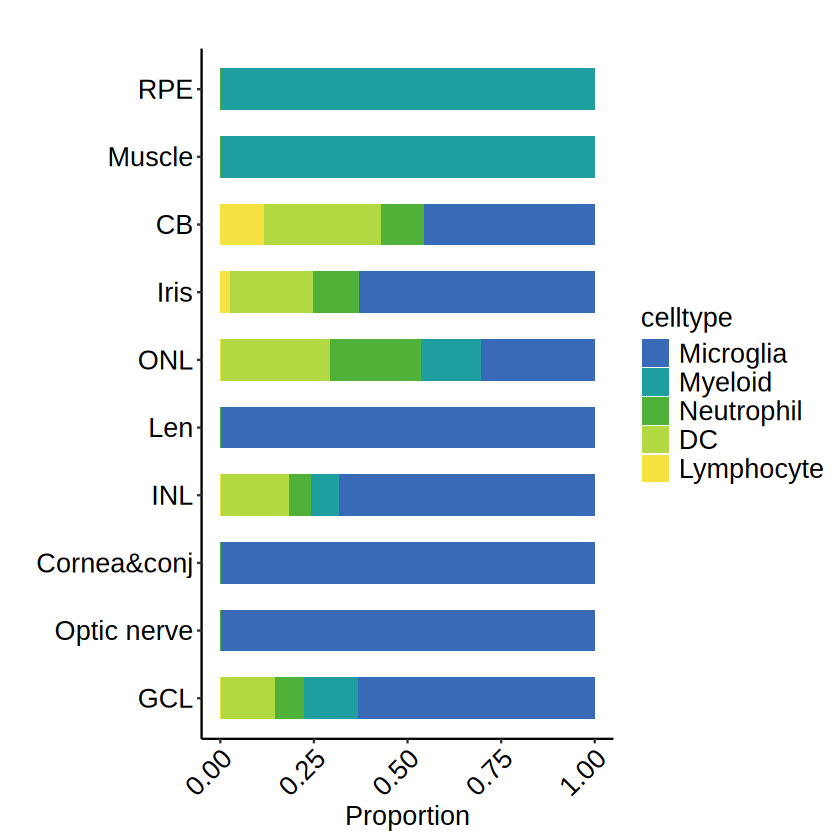

In [74]:
plot_df <- melt(m1)
colnames(plot_df) <- c('celltype','y','sum')
plot_df$y <- factor(plot_df$y, levels = area)
plot_df$celltype <- factor(plot_df$celltype,levels = c('Microglia','Myeloid','Neutrophil','DC','Lymphocyte'))
plot_df$score <- NA
plot_df$cor <- 0
for (a in 1:nrow(plot_df)) {
  plot_df[a,'score'] <- sum(plot_df$sum[which(plot_df$y==plot_df$y[a])])
}
p1 <- ggplot(plot_df, mapping = aes(y,sum,fill=celltype))+geom_bar(stat='identity',position="fill",width = 0.6)+
labs(x = "",y = 'Proportion',title = "") +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title= element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'),
    axis.line.x = element_line (color = 'black',linetype = 'solid'), 
    panel.background=element_rect(fill="white"))+scale_fill_manual(values =cols)+coord_flip()
p1
ggsave("eye_area_RIR_imm_Proportion.pdf",p1,width = 7,height = 6)